# YOLO11 Multi-Class Anomaly Type Detection — MVTec 3D-AD

This notebook trains a **YOLO11 instance segmentation** model that:
- Detects whether an image is **NORMAL** or has an **ANOMALY**
- If anomaly → identifies the **exact type** (crack, hole, contamination, cut, etc.)

## Key difference from binary notebook
Instead of 1 class `anomaly`, each defect type is its own class:
- `bent`, `color`, `combined`, `contamination`, `crack`, `cut`, `hole`, `scratch`, `thread`, ...

## Pipeline
1. Build class mapping from dataset
2. EDA — visualise images, masks, class distribution
3. Convert GT masks → YOLO polygon labels (multi-class)
4. Build YOLO dataset directory + `data.yaml`
5. Offline data augmentation
6. Train YOLO11-seg
7. Evaluate & visualise predictions
8. **Single-image prediction: NORMAL vs ANOMALY TYPE**

## 0. Install Dependencies

In [1]:
!pip install ultralytics opencv-python-headless matplotlib numpy Pillow tqdm scikit-learn albumentations pandas -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports & Configuration

In [23]:
import os
import json
import shutil
import random
import warnings
from pathlib import Path
from collections import defaultdict, Counter

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATASET_ROOT = Path(r'c:/Users/ilias/Downloads/mvtec_3d_anomaly_detection')
YOLO_ROOT    = DATASET_ROOT / 'yolo_multiclass_dataset'   # separate from binary notebook

CATEGORIES = [
    'bagel', 'cable_gland', 'carrot', 'cookie',
    'dowel', 'foam', 'peach', 'potato', 'rope', 'tire'
]

# ── YOLO hyperparams ──────────────────────────────────────────────────────────
IMG_SIZE         = 800
TRAIN_SPLIT      = 0.80
MIN_CONTOUR_AREA = 50

print(f'Dataset root : {DATASET_ROOT}')
print(f'YOLO output  : {YOLO_ROOT}')

Dataset root : c:\Users\ilias\Downloads\mvtec_3d_anomaly_detection
YOLO output  : c:\Users\ilias\Downloads\mvtec_3d_anomaly_detection\yolo_multiclass_dataset


## 2. Build Class Mapping

Scan all category/test/* directories to collect every defect type name,
then assign a numeric class ID to each one.

In [24]:
# ── 2.1  Discover all defect types across all categories ──────────────────────
# 'combined' is NOT a class — it means one image contains multiple defect types.
# It is excluded here and expanded into per-class samples in collect_defect_samples().
all_defect_types = set()
for cat in CATEGORIES:
    test_root = DATASET_ROOT / cat / 'test'
    if not test_root.exists():
        continue
    for d in test_root.iterdir():
        if d.is_dir() and d.name not in ('good', 'combined'):
            all_defect_types.add(d.name)

CLASS_NAMES = sorted(all_defect_types)
CLASS_MAP   = {name: idx for idx, name in enumerate(CLASS_NAMES)}
NC          = len(CLASS_NAMES)

print(f'Found {NC} defect types (excluding "combined"):')
for name, idx in CLASS_MAP.items():
    print(f'  {idx:2d} : {name}')

(DATASET_ROOT / 'class_ids.json').write_text(json.dumps(CLASS_MAP, indent=2))
print(f'\nSaved to {DATASET_ROOT / "class_ids.json"}')


Found 9 defect types:
   0 : bent
   1 : color
   2 : combined
   3 : contamination
   4 : crack
   5 : cut
   6 : hole
   7 : open
   8 : thread

Saved to c:\Users\ilias\Downloads\mvtec_3d_anomaly_detection\class_ids.json


In [25]:
# ── 2.2  Per-category defect type breakdown ────────────────────────────────────
cat_defect_map = {}
for cat in CATEGORIES:
    test_root = DATASET_ROOT / cat / 'test'
    defects = sorted([
        d.name for d in test_root.iterdir()
        if d.is_dir() and d.name != 'good'
    ])
    cat_defect_map[cat] = defects
    ids = [CLASS_MAP[d] for d in defects]
    print(f'{cat:<15}: {defects}  →  class IDs {ids}')

bagel          : ['combined', 'contamination', 'crack', 'hole']  →  class IDs [2, 3, 4, 6]
cable_gland    : ['bent', 'cut', 'hole', 'thread']  →  class IDs [0, 5, 6, 8]
carrot         : ['combined', 'contamination', 'crack', 'cut', 'hole']  →  class IDs [2, 3, 4, 5, 6]
cookie         : ['combined', 'contamination', 'crack', 'hole']  →  class IDs [2, 3, 4, 6]
dowel          : ['bent', 'combined', 'contamination', 'cut']  →  class IDs [0, 2, 3, 5]
foam           : ['color', 'combined', 'contamination', 'cut']  →  class IDs [1, 2, 3, 5]
peach          : ['combined', 'contamination', 'cut', 'hole']  →  class IDs [2, 3, 5, 6]
potato         : ['combined', 'contamination', 'cut', 'hole']  →  class IDs [2, 3, 5, 6]
rope           : ['contamination', 'cut', 'open']  →  class IDs [3, 5, 7]
tire           : ['combined', 'contamination', 'cut', 'hole']  →  class IDs [2, 3, 5, 6]


## 3. Exploratory Data Analysis

In [26]:
# ── 3.1  Count images per category / split / defect type ──────────────────────
stats = []
for cat in CATEGORIES:
    cat_path   = DATASET_ROOT / cat
    train_good = len(list((cat_path / 'train' / 'good' / 'rgb').glob('*.png')))
    val_good   = len(list((cat_path / 'validation' / 'good' / 'rgb').glob('*.png')))
    defect_types = cat_defect_map[cat]
    defect_imgs  = sum(
        len(list((cat_path / 'test' / d / 'rgb').glob('*.png')))
        for d in defect_types
    )
    good_test = len(list((cat_path / 'test' / 'good' / 'rgb').glob('*.png')))
    stats.append({
        'category'    : cat,
        'train_good'  : train_good,
        'val_good'    : val_good,
        'test_good'   : good_test,
        'test_defect' : defect_imgs,
        'defect_types': defect_types,
    })

print(f'{"Category":<15} {"Train(good)":>12} {"Val(good)":>10} {"Test(good)":>11} {"Test(defect)":>13}  Defect types')
print('-'*90)
total_defect = 0
for s in stats:
    print(f"{s['category']:<15} {s['train_good']:>12} {s['val_good']:>10} "
          f"{s['test_good']:>11} {s['test_defect']:>13}  {s['defect_types']}")
    total_defect += s['test_defect']
print('-'*90)
print(f'Total labelled defect images: {total_defect}')

Category         Train(good)  Val(good)  Test(good)  Test(defect)  Defect types
------------------------------------------------------------------------------------------
bagel                    244         22          22            88  ['combined', 'contamination', 'crack', 'hole']
cable_gland              223         23          21            87  ['bent', 'cut', 'hole', 'thread']
carrot                   286         29          27           132  ['combined', 'contamination', 'crack', 'cut', 'hole']
cookie                   210         22          28           103  ['combined', 'contamination', 'crack', 'hole']
dowel                    288         34          26           104  ['bent', 'combined', 'contamination', 'cut']
foam                     236         27          20            80  ['color', 'combined', 'contamination', 'cut']
peach                    361         42          26           106  ['combined', 'contamination', 'cut', 'hole']
potato                   300         33   

In [27]:
# ── 3.2  Class distribution bar chart ─────────────────────────────────────────
class_counts = defaultdict(int)
for cat in CATEGORIES:
    for defect in cat_defect_map[cat]:
        n = len(list((DATASET_ROOT / cat / 'test' / defect / 'rgb').glob('*.png')))
        class_counts[defect] += n

fig, ax = plt.subplots(figsize=(14, 5))
names  = list(class_counts.keys())
counts = list(class_counts.values())
colors = plt.cm.tab20(np.linspace(0, 1, len(names)))
ax.bar(names, counts, color=colors, edgecolor='white')
ax.set_title('Number of images per anomaly type (all categories combined)', fontsize=13)
ax.set_xlabel('Anomaly type')
ax.set_ylabel('# images')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(DATASET_ROOT / 'eda_class_distribution.png', dpi=120)
plt.show()

<Figure size 1400x500 with 1 Axes>

In [28]:
# ── 3.3  Visualise sample images per anomaly type ─────────────────────────────
sample_pairs = [
    ('bagel',       'crack'),
    ('bagel',       'hole'),
    ('cable_gland', 'bent'),
    ('carrot',      'cut'),
    ('cookie',      'contamination'),
    ('dowel',       'combined'),
]

fig, axes = plt.subplots(len(sample_pairs), 3, figsize=(14, 3.5 * len(sample_pairs)))
for row, (cat, defect) in enumerate(sample_pairs):
    base      = DATASET_ROOT / cat / 'test' / defect
    rgb_files = sorted((base / 'rgb').glob('*.png'))
    gt_files  = sorted((base / 'gt').glob('*.png'))
    if not rgb_files:
        continue
    rgb     = np.array(Image.open(rgb_files[0]))
    gt      = np.array(Image.open(gt_files[0])) if gt_files else np.zeros(rgb.shape[:2], np.uint8)
    overlay = rgb.copy()
    overlay[gt > 0] = (overlay[gt > 0] * 0.4 + np.array([255, 0, 0]) * 0.6).astype(np.uint8)
    class_id = CLASS_MAP[defect]
    axes[row, 0].imshow(rgb);                  axes[row, 0].set_title(f'{cat}/{defect} (class {class_id}) — RGB')
    axes[row, 1].imshow(gt, cmap='hot');       axes[row, 1].set_title('GT Mask')
    axes[row, 2].imshow(overlay);              axes[row, 2].set_title('Overlay (red = anomaly)')
    for ax in axes[row]: ax.axis('off')

plt.suptitle('MVTec 3D-AD — Sample anomaly types', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(DATASET_ROOT / 'eda_multiclass_samples.png', dpi=100, bbox_inches='tight')
plt.show()

<Figure size 1400x2100 with 18 Axes>

## 4. GT Mask → YOLO Polygon Labels (Multi-Class)

Same as binary notebook but `class_id` is passed per sample based on its defect folder name.

In [29]:
def mask_to_yolo_polygons(mask: np.ndarray, class_id: int,
                           min_area: int = MIN_CONTOUR_AREA) -> list:
    """
    Convert a grayscale GT mask to YOLO segmentation label lines.

    Parameters
    ----------
    mask     : H×W uint8 array, non-zero pixels = anomaly
    class_id : YOLO class index for this defect type
    min_area : discard contours smaller than this (noise)

    Returns
    -------
    List of label strings, one per contour:
        "<class_id>  x1 y1 x2 y2 ... xN yN"
    """
    H, W   = mask.shape[:2]
    binary = (mask > 0).astype(np.uint8) * 255
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    lines = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue
        epsilon = 0.002 * cv2.arcLength(cnt, True)
        approx  = cv2.approxPolyDP(cnt, epsilon, True)
        if len(approx) < 3:
            continue
        pts = approx.reshape(-1, 2).astype(float)
        pts[:, 0] /= W
        pts[:, 1] /= H
        pts = pts.clip(0, 1)
        coords = ' '.join(f'{x:.6f} {y:.6f}' for x, y in pts)
        lines.append(f'{class_id} {coords}')
    return lines


# Quick sanity check
test_gt_path = DATASET_ROOT / 'bagel' / 'test' / 'crack' / 'gt' / '000.png'
test_gt      = np.array(Image.open(test_gt_path))
test_cid     = CLASS_MAP['crack']
lines        = mask_to_yolo_polygons(test_gt, test_cid)
print(f'GT mask shape : {test_gt.shape}, unique vals: {np.unique(test_gt)}')
print(f'Class ID for "crack" : {test_cid}')
print(f'Generated {len(lines)} label line(s)')
if lines:
    print('First 80 chars of line 0:', lines[0][:80], '...')

GT mask shape : (800, 800), unique vals: [  0 254]
Class ID for "crack" : 4
Generated 1 label line(s)
First 80 chars of line 0: 4 0.515000 0.588750 0.512500 0.591250 0.507500 0.605000 0.498750 0.610000 0.4987 ...


In [30]:
# ── Visualise polygon extraction for several defect types ─────────────────────
def visualise_polygon_extraction(cat, defect, idx=0):
    base  = DATASET_ROOT / cat / 'test' / defect
    rgb_f = sorted((base / 'rgb').glob('*.png'))[idx]
    gt_f  = sorted((base / 'gt' ).glob('*.png'))[idx]
    rgb   = np.array(Image.open(rgb_f))
    gt    = np.array(Image.open(gt_f))
    cid   = CLASS_MAP[defect]
    lines = mask_to_yolo_polygons(gt, cid)

    H, W   = gt.shape
    canvas = rgb.copy()
    for line in lines:
        parts  = line.split()
        coords = np.array(parts[1:], dtype=float).reshape(-1, 2)
        coords[:, 0] *= W; coords[:, 1] *= H
        pts = coords.astype(np.int32).reshape((-1, 1, 2))
        cv2.polylines(canvas, [pts], True, (0, 255, 0), 2)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(rgb);              axes[0].set_title('RGB')
    axes[1].imshow(gt, cmap='hot');   axes[1].set_title('GT Mask')
    axes[2].imshow(canvas);           axes[2].set_title(f'YOLO Polygons — class {cid} ({defect})')
    for ax in axes: ax.axis('off')
    plt.suptitle(f'{cat} / {defect}', fontsize=13)
    plt.tight_layout()
    plt.show()

visualise_polygon_extraction('bagel',       'crack')
visualise_polygon_extraction('cable_gland', 'bent')
visualise_polygon_extraction('cookie',      'hole')

<Figure size 1400x400 with 3 Axes>

<Figure size 1400x400 with 3 Axes>

<Figure size 1400x400 with 3 Axes>

## 5. Build YOLO Multi-Class Dataset

In [32]:
# MVTec 3D-AD encodes each defect in the mask by pixel value: 255 - alphabetical_rank
# e.g. bagel: contamination=255, crack=254, hole=253
# Build per-category pixel-value -> defect mapping for 'combined' GT decoding.
CAT_PIXEL_MAP = {}
for cat in CATEGORIES:
    test_root = DATASET_ROOT / cat / 'test'
    if not test_root.exists():
        continue
    non_combined = sorted([
        d.name for d in test_root.iterdir()
        if d.is_dir() and d.name not in ('good', 'combined')
    ])
    CAT_PIXEL_MAP[cat] = {255 - i: defect for i, defect in enumerate(non_combined)}

print('Per-category pixel -> defect mapping:')
for cat, pmap in sorted(CAT_PIXEL_MAP.items()):
    print(f'  {cat:<15}: {pmap}')


def collect_defect_samples(dataset_root, categories):
    """
    Collect all samples with non-empty GT masks.
    'combined' images are expanded: one sample per defect type encoded in the GT.
    Each sample has 'gt_mask': a binary uint8 numpy array (0/255) for the specific
    class, or None for single-defect samples (load from 'gt' path at use time).
    """
    samples = []
    for cat in categories:
        test_root = dataset_root / cat / 'test'
        for defect_dir in sorted(test_root.iterdir()):
            if not defect_dir.is_dir() or defect_dir.name == 'good':
                continue
            rgb_dir = defect_dir / 'rgb'
            gt_dir  = defect_dir / 'gt'
            if not rgb_dir.exists() or not gt_dir.exists():
                continue

            is_combined = (defect_dir.name == 'combined')

            for rgb_f in sorted(rgb_dir.glob('*.png')):
                gt_f = gt_dir / rgb_f.name
                if not gt_f.exists():
                    continue
                gt_arr = np.array(Image.open(gt_f))
                if gt_arr.max() == 0:
                    continue

                if is_combined:
                    # Expand: one sample per defect type present in this GT
                    for pval, defect_name in CAT_PIXEL_MAP.get(cat, {}).items():
                        if defect_name not in CLASS_MAP:
                            continue
                        binary_mask = (gt_arr == pval).astype(np.uint8) * 255
                        if binary_mask.max() == 0:
                            continue
                        samples.append({
                            'rgb'     : rgb_f,
                            'gt'      : gt_f,
                            'gt_mask' : binary_mask,
                            'cat'     : cat,
                            'defect'  : defect_name,
                            'class_id': CLASS_MAP[defect_name],
                        })
                else:
                    samples.append({
                        'rgb'     : rgb_f,
                        'gt'      : gt_f,
                        'gt_mask' : None,
                        'cat'     : cat,
                        'defect'  : defect_dir.name,
                        'class_id': CLASS_MAP[defect_dir.name],
                    })
    return samples


all_samples = collect_defect_samples(DATASET_ROOT, CATEGORIES)
print(f'\nTotal samples (combined expanded): {len(all_samples)}')
per_class = Counter(s['defect'] for s in all_samples)
for defect, cnt in sorted(per_class.items()):
    print(f'  class {CLASS_MAP[defect]:2d} | {defect:<20}: {cnt} images')


Total usable defect samples: 948
  class  0 | bent                : 48 images
  class  1 | color               : 20 images
  class  2 | combined            : 174 images
  class  3 | contamination       : 223 images
  class  4 | crack               : 75 images
  class  5 | cut                 : 195 images
  class  6 | hole                : 174 images
  class  7 | open                : 17 images
  class  8 | thread              : 22 images


In [33]:
# ── Train / Val split stratified by defect class ──────────────────────────────
labels_for_split = [s['defect'] for s in all_samples]
train_samples, val_samples = train_test_split(
    all_samples,
    test_size=1 - TRAIN_SPLIT,
    random_state=42,
    stratify=labels_for_split,
)
print(f'Train : {len(train_samples)} images')
print(f'Val   : {len(val_samples)}  images')

Train : 758 images
Val   : 190  images


In [12]:
def build_yolo_dataset(train_samples, val_samples, yolo_root: Path):
    """Write images and multi-class label files in YOLO segmentation format."""
    for split, samples in [('train', train_samples), ('val', val_samples)]:
        img_dir = yolo_root / 'images' / split
        lbl_dir = yolo_root / 'labels' / split
        img_dir.mkdir(parents=True, exist_ok=True)
        lbl_dir.mkdir(parents=True, exist_ok=True)

        skipped = 0
        for s in tqdm(samples, desc=f'Building {split}'):
            stem = f"{s['cat']}_{s['defect']}_{s['rgb'].stem}"

            # Image
            rgb_arr = np.array(Image.open(s['rgb']).convert('RGB'))
            rgb_arr = cv2.resize(rgb_arr, (IMG_SIZE, IMG_SIZE),
                                  interpolation=cv2.INTER_LINEAR)
            cv2.imwrite(
                str(img_dir / f'{stem}.jpg'),
                cv2.cvtColor(rgb_arr, cv2.COLOR_RGB2BGR),
                [cv2.IMWRITE_JPEG_QUALITY, 95],
            )

            # Label  ← use the sample's specific class_id
            gt_arr = s['gt_mask'] if s['gt_mask'] is not None else np.array(Image.open(s['gt']))
            lines  = mask_to_yolo_polygons(gt_arr, s['class_id'])
            if not lines:
                skipped += 1
                (lbl_dir / f'{stem}.txt').write_text('')
                continue
            (lbl_dir / f'{stem}.txt').write_text('\n'.join(lines))

        print(f'  {split}: {len(samples)} total, {skipped} skipped (no polygon)')


if YOLO_ROOT.exists():
    shutil.rmtree(YOLO_ROOT)

build_yolo_dataset(train_samples, val_samples, YOLO_ROOT)
print(f'\nYOLO dataset written to: {YOLO_ROOT}')

Building train: 100%|██████████| 758/758 [00:29<00:00, 25.55it/s]


  train: 758 total, 1 skipped (no polygon)


Building val: 100%|██████████| 190/190 [00:07<00:00, 24.23it/s]

  val: 190 total, 0 skipped (no polygon)

YOLO dataset written to: c:\Users\ilias\Downloads\mvtec_3d_anomaly_detection\yolo_multiclass_dataset


In [2]:
# ── Write data.yaml with all anomaly type classes ─────────────────────────────
names_yaml = '\n'.join(f'  {idx}: {name}' for name, idx in CLASS_MAP.items())

yaml_content = f"""# MVTec 3D-AD — YOLO Multi-Class Anomaly Type Dataset
# Each class = one defect type (e.g. crack, hole, contamination ...)

path: {YOLO_ROOT.as_posix()}
train: images/train
val:   images/val

nc: {NC}
names:
{names_yaml}
"""

yaml_path = YOLO_ROOT / 'data.yaml'
yaml_path.write_text(yaml_content)
print(yaml_path.read_text())

NameError: name 'CLASS_MAP' is not defined

In [14]:
# ── Sanity check label files ───────────────────────────────────────────────────
train_imgs   = list((YOLO_ROOT / 'images' / 'train').glob('*.jpg'))
train_labels = list((YOLO_ROOT / 'labels' / 'train').glob('*.txt'))
val_imgs     = list((YOLO_ROOT / 'images' / 'val').glob('*.jpg'))
val_labels   = list((YOLO_ROOT / 'labels' / 'val').glob('*.txt'))

print(f'Train images : {len(train_imgs):>5}')
print(f'Train labels : {len(train_labels):>5}')
print(f'Val   images : {len(val_imgs):>5}')
print(f'Val   labels : {len(val_labels):>5}')

# Show a sample label — should show the class id of the defect, not always 0
sample_lbl = next(l for l in train_labels if l.read_text().strip())
content    = sample_lbl.read_text().strip()
class_used = int(content.split()[0])
print(f'\nSample label ({sample_lbl.name}):')
print(f'  class_id = {class_used}  ({CLASS_NAMES[class_used]})')
for line in content.split('\n')[:2]:
    print(' ', line[:90], '...' if len(line) > 90 else '')

Train images :   758
Train labels :   758
Val   images :   190
Val   labels :   190

Sample label (bagel_combined_000.txt):
  class_id = 2  (combined)
  2 0.455000 0.558750 0.446250 0.563750 0.440000 0.585000 0.428750 0.591250 0.426250 0.59625 ...
  2 0.307500 0.275000 0.307500 0.278750 0.306250 0.280000 0.306250 0.283750 0.307500 0.28500 ...


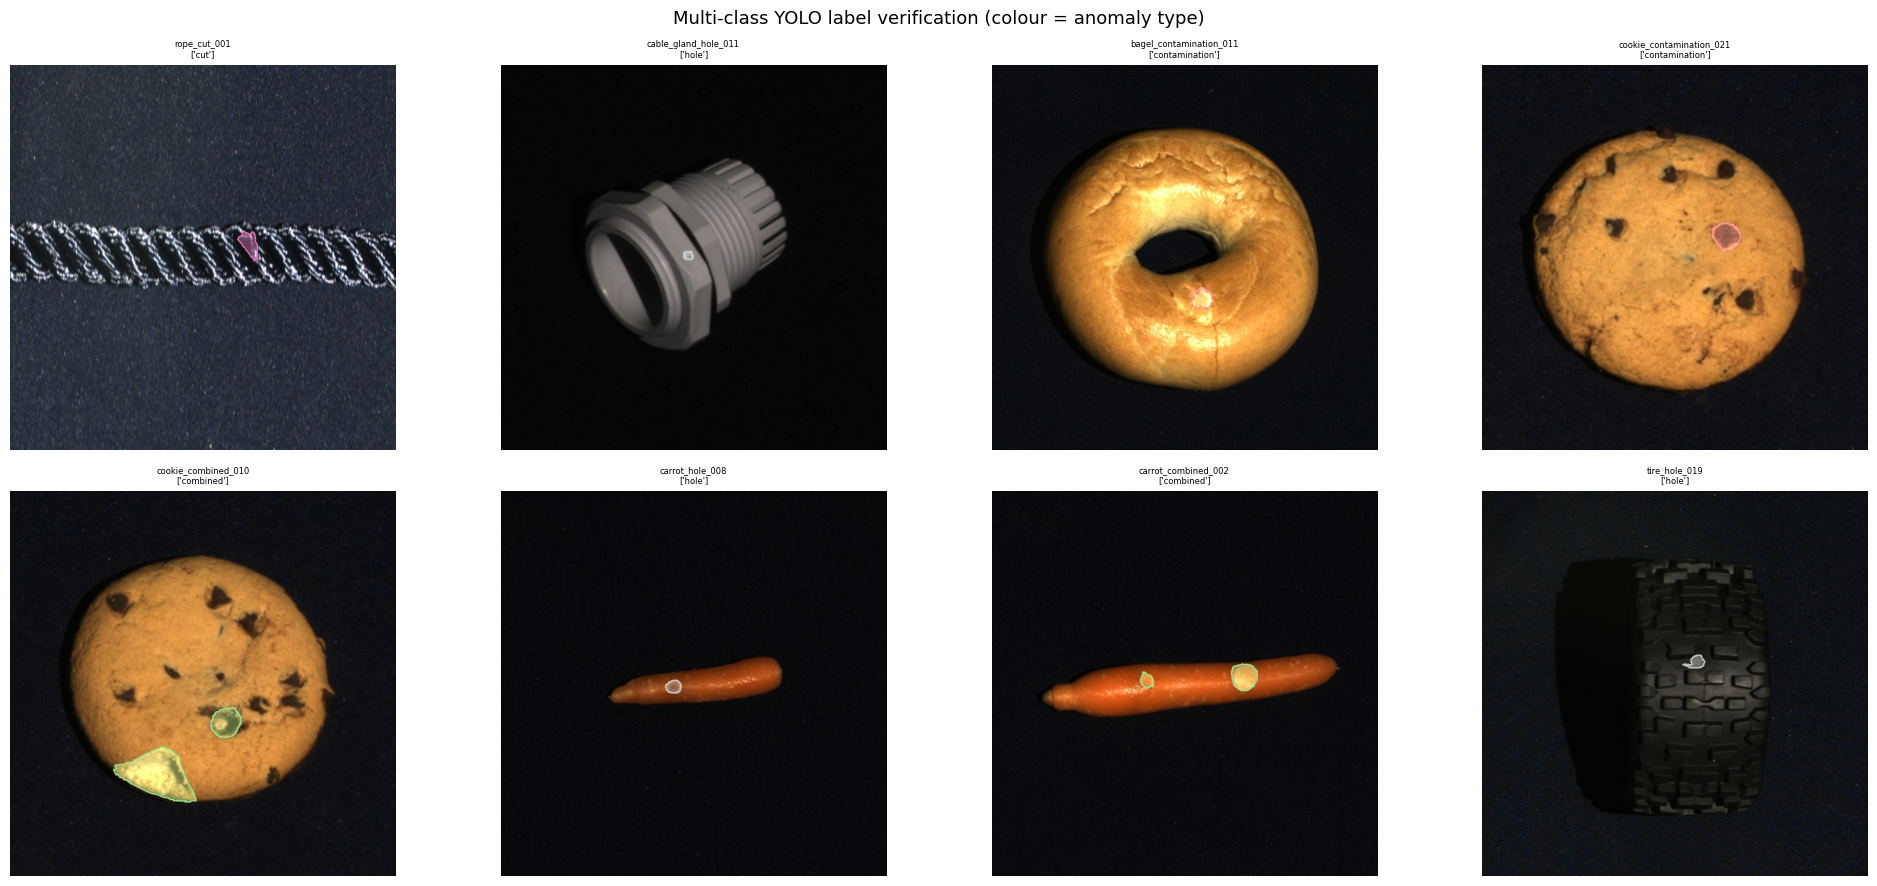

In [15]:
# ── Verify labels visually ────────────────────────────────────────────────────
COLORS = plt.cm.tab20(np.linspace(0, 1, NC))

def draw_yolo_labels_multiclass(img_path: Path, lbl_path: Path):
    img     = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    H, W    = img.shape[:2]
    overlay = img.copy()
    content = lbl_path.read_text().strip()
    legend  = []
    if not content:
        return overlay, []
    for line in content.split('\n'):
        parts    = line.split()
        cid      = int(parts[0])
        coords   = np.array(parts[1:], dtype=float).reshape(-1, 2)
        coords[:, 0] *= W; coords[:, 1] *= H
        pts      = coords.astype(np.int32)
        color_f  = COLORS[cid % len(COLORS)]
        color_u8 = tuple(int(c * 255) for c in color_f[:3])
        layer    = np.zeros_like(img)
        cv2.fillPoly(layer, [pts.reshape(-1, 1, 2)], color_u8)
        overlay  = cv2.addWeighted(overlay, 1.0, layer, 0.4, 0)
        cv2.polylines(overlay, [pts.reshape(-1, 1, 2)], True, color_u8, 2)
        legend.append(CLASS_NAMES[cid])
    return overlay, list(set(legend))


n_show  = 8
samples = random.sample(train_imgs, n_show)
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, img_f in zip(axes.flatten(), samples):
    lbl_f   = YOLO_ROOT / 'labels' / 'train' / img_f.with_suffix('.txt').name
    vis, leg = draw_yolo_labels_multiclass(img_f, lbl_f)
    ax.imshow(vis)
    ax.set_title(f'{img_f.stem[:28]}\n{leg}', fontsize=6)
    ax.axis('off')

plt.suptitle('Multi-class YOLO label verification (colour = anomaly type)', fontsize=13)
plt.tight_layout()
plt.savefig(DATASET_ROOT / 'multiclass_label_verification.png', dpi=100)
plt.show()

## 6. Offline Data Augmentation

In [16]:
import albumentations as A

AUG_MULTIPLIER = 5

spatial_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.4),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.08, scale_limit=0.15, rotate_limit=20,
        border_mode=cv2.BORDER_REFLECT_101, p=0.6
    ),
    A.ElasticTransform(alpha=40, sigma=5,
                        border_mode=cv2.BORDER_REFLECT_101, p=0.25),
    A.GridDistortion(num_steps=5, distort_limit=0.2, p=0.2),
    A.Perspective(scale=(0.03, 0.08), p=0.2),
], additional_targets={'mask': 'mask'})

photo_aug = A.Compose([
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.25, hue=0.06, p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.CLAHE(clip_limit=2.5, tile_grid_size=(8, 8), p=0.25),
    A.GaussNoise(var_limit=(5.0, 40.0), p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.ImageCompression(quality_lower=75, quality_upper=100, p=0.2),
    A.ToGray(p=0.05),
    A.CoarseDropout(
        max_holes=6, max_height=30, max_width=30,
        min_holes=1, min_height=8,  min_width=8,
        fill_value=0, p=0.2
    ),
])

print(f'AUG_MULTIPLIER = {AUG_MULTIPLIER}  →  each training image produces {AUG_MULTIPLIER} extra copies')

AUG_MULTIPLIER = 5  →  each training image produces 5 extra copies


In [17]:
def augment_training_set(train_samples, img_dir, lbl_dir, multiplier=AUG_MULTIPLIER):
    written = skipped = 0
    for s in tqdm(train_samples, desc='Augmenting train set'):
        stem      = f"{s['cat']}_{s['defect']}_{s['rgb'].stem}"
        img_full  = np.array(Image.open(s['rgb']).convert('RGB'))
        mask_full = s['gt_mask'] if s['gt_mask'] is not None else np.array(Image.open(s['gt']))
        img_res   = cv2.resize(img_full,  (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
        mask_res  = cv2.resize(mask_full, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

        for aug_idx in range(multiplier):
            sp_result = spatial_aug(image=img_res, mask=mask_res)
            aug_img   = photo_aug(image=sp_result['image'])['image']
            aug_mask  = sp_result['mask']

            # Use the sample's class_id (not always 0!)
            lines = mask_to_yolo_polygons(aug_mask, s['class_id'])
            if not lines:
                skipped += 1
                continue

            out_stem = f'{stem}_aug{aug_idx:02d}'
            cv2.imwrite(
                str(img_dir / f'{out_stem}.jpg'),
                cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR),
                [cv2.IMWRITE_JPEG_QUALITY, 95],
            )
            (lbl_dir / f'{out_stem}.txt').write_text('\n'.join(lines))
            written += 1

    print(f'  Written : {written}')
    print(f'  Skipped : {skipped}  (mask vanished after spatial transform)')
    return written


n_written = augment_training_set(
    train_samples,
    img_dir=YOLO_ROOT / 'images' / 'train',
    lbl_dir=YOLO_ROOT / 'labels' / 'train',
)

total_train = len(list((YOLO_ROOT / 'images' / 'train').glob('*.jpg')))
print(f'\nTrain before augmentation : {len(train_samples)} images')
print(f'Train after  augmentation : {total_train} images')
print(f'Effective multiplier      : {total_train / max(len(train_samples), 1):.1f}x')

Augmenting train set: 100%|██████████| 758/758 [08:35<00:00,  1.47it/s]


  Written : 3790
  Skipped : 0  (mask vanished after spatial transform)

Train before augmentation : 758 images
Train after  augmentation : 4548 images
Effective multiplier      : 6.0x


## 7. Train YOLO11 Segmentation Model

In [3]:
from ultralytics import YOLO
import torch
yaml_path = YOLO_ROOT / 'data.yaml'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU   : NVIDIA GeForce RTX 4050 Laptop GPU
VRAM  : 6.4 GB


In [4]:
# ── Compute class weights to handle class imbalance ─────────────────────────
from collections import Counter
import numpy as np

train_lbl_dir = YOLO_ROOT / 'labels' / 'train'

# Count instances per class across all training label files
class_counts = Counter()
for lbl_file in train_lbl_dir.glob('*.txt'):
    for line in lbl_file.read_text().splitlines():
        if line.strip():
            class_counts[int(line.split()[0])] += 1

# Fill missing classes with 1 to avoid division by zero
counts = np.array([class_counts.get(i, 1) for i in range(NC)], dtype=float)
total  = counts.sum()

# Inverse-frequency weights, normalised so the median weight = 1
raw_weights = total / (NC * counts)
class_weights = raw_weights / np.median(raw_weights)

# cls_pw: scalar passed to YOLO — use the mean weight of under-represented classes
# (YOLO applies a single positive-class weight to the BCE classification loss)
cls_pw_value = float(np.mean(class_weights[class_weights > 1.0])) if (class_weights > 1.0).any() else 1.0

print(f'Class instance counts and weights (sorted by count):')
print(f'{"Class":<20} {"Count":>8}  {"Weight":>8}')
print('-' * 42)
order = np.argsort(counts)
for idx in order:
    print(f'{CLASS_NAMES[idx]:<20} {int(counts[idx]):>8}  {class_weights[idx]:>8.3f}')
print(f'cls_pw used for training : {cls_pw_value:.3f}')


KeyboardInterrupt: 

In [5]:
# ── Model & training config ───────────────────────────────────────────────────
MODEL_NAME  = 'yolo26n-seg.pt'   # change to yolo11x-seg.pt for best accuracy
EPOCHS      = 150
BATCH_SIZE  = 16
LR0         = 1e-3
LRF         = 0.01
PATIENCE    = 10
PROJECT_DIR = DATASET_ROOT / 'runs' / 'segment_multiclass'
RUN_NAME    = 'mvtec3d_anomaly_type'

model = YOLO(MODEL_NAME)

results = model.train(
    data      = str(yaml_path),
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH_SIZE,
    device    = DEVICE,
    lr0       = LR0,
    lrf       = LRF,
    patience  = PATIENCE,
    project   = str(PROJECT_DIR),
    name      = RUN_NAME,
    save      = True,
    plots     = True,
    mosaic    = 1.0,
    mixup     = 0.1,
    flipud    = 0.3,
    fliplr    = 0.5,
    degrees   = 10.0,
    translate = 0.1,
    scale     = 0.5,
    hsv_h     = 0.015,
    hsv_s     = 0.7,
    hsv_v     = 0.4,
    workers   = 4,
    verbose   = True,)       # Focal Loss gamma: down-weights easy examples, focus on rare classe

print('Training complete!')


New https://pypi.org/project/ultralytics/8.4.37 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.30  Python-3.10.18 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\ilias\Downloads\mvtec_3d_anomaly_detection\yolo_multiclass_dataset\data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, mod

In [ ]:
# ── Reset matplotlib backend after YOLO training ─────────────────────────────
# YOLO internally switches matplotlib to 'Agg' during training,
# which breaks plt.show() in all subsequent cells.
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
plt.rcParams.update(plt.rcParamsDefault)
print('Matplotlib backend reset to inline — figures will display correctly.')


## 8. Training Curves

In [7]:
import pandas as pd

run_dir  = PROJECT_DIR / 'mvtec3d_anomaly_type3'
csv_path = run_dir / 'results.csv'
df       = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics_to_plot = [
    ('train/box_loss',      'Train Box Loss'),
    ('train/seg_loss',      'Train Seg Loss'),
    ('val/box_loss',        'Val Box Loss'),
    ('val/seg_loss',        'Val Seg Loss'),
    ('metrics/mAP50(M)',    'mAP@0.5 (Mask)'),
    ('metrics/mAP50-95(M)', 'mAP@0.5:0.95 (Mask)'),
]
for ax, (col, title) in zip(axes.flatten(), metrics_to_plot):
    if col in df.columns:
        ax.plot(df['epoch'], df[col])
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)
    else:
        ax.set_title(f'{title} (not found)', fontsize=10)

plt.suptitle('YOLO11-seg Multi-Class Training Curves — MVTec 3D-AD', fontsize=14)
plt.tight_layout()
plt.savefig(run_dir / 'training_curves.png', dpi=120)
plt.show()

<Figure size 1800x1000 with 6 Axes>

## 9. Evaluate on Validation Set

In [8]:
best_model_path = run_dir / 'weights' / 'best.pt'
best_model      = YOLO(str(best_model_path))

val_metrics = best_model.val(
    data   = str(yaml_path),
    split  = 'val',
    imgsz  = IMG_SIZE,
    device = DEVICE,
    plots  = True,
)

print('\n── Validation Metrics ──────────────────────────────')
print(f'  Box  mAP@0.50      : {val_metrics.box.map50:.4f}')
print(f'  Box  mAP@0.50:0.95 : {val_metrics.box.map:.4f}')
print(f'  Mask mAP@0.50      : {val_metrics.seg.map50:.4f}')
print(f'  Mask mAP@0.50:0.95 : {val_metrics.seg.map:.4f}')

Ultralytics 8.4.30  Python-3.10.18 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
YOLO26n-seg summary (fused): 139 layers, 2,690,639 parameters, 0 gradients, 9.0 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 736.4258.9 MB/s, size: 129.0 KB)
val: Scanning C:\Users\ilias\Downloads\mvtec_3d_anomaly_detection\yolo_multiclass_dataset\labels\val.cache... 190 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 190/190  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 2.2it/s 5.6s0.3s
                   all        190        226      0.591      0.705      0.664      0.399       0.58      0.694       0.65      0.363
                  bent         10         10      0.685        0.8      0.631      0.244      0.598        0.7      0.505      0.256
                 color          4          4      0.683          1      0.945      0.633      0.682      

In [11]:
# ── Per-class mAP ─────────────────────────────────────────────────────────────
print('\nPer-class mAP@0.50 (Mask):')
if hasattr(val_metrics.seg, 'ap_class_index'):
    for idx, ap in zip(val_metrics.seg.ap_class_index, val_metrics.seg.ap):
        print(f'  class {idx:2d} | {CLASS_NAMES[idx]:<20}: mAP50 = {ap:.4f}')
else:
    print('  (per-class metrics not available in this ultralytics version)')


Per-class mAP@0.50 (Mask):
  class  0 | bent                : mAP50 = 0.2562
  class  1 | color               : mAP50 = 0.6548
  class  2 | combined            : mAP50 = 0.1366
  class  3 | contamination       : mAP50 = 0.2365
  class  4 | crack               : mAP50 = 0.3973
  class  5 | cut                 : mAP50 = 0.2540
  class  6 | hole                : mAP50 = 0.2292
  class  7 | open                : mAP50 = 0.5499
  class  8 | thread              : mAP50 = 0.5555


In [ ]:
# ── Per-class metrics: expose class imbalance impact ────────────────────────
import numpy as np

seg = val_metrics.seg

if hasattr(seg, 'ap_class_index') and seg.ap_class_index is not None:
    class_indices = list(seg.ap_class_index)
    ap50_per_cls  = (seg.ap[:, 0].tolist() if seg.ap.ndim == 2 else seg.ap.tolist())
    p_per_cls     = seg.p.tolist() if (hasattr(seg, 'p') and seg.p is not None) else [None] * len(class_indices)
    r_per_cls     = seg.r.tolist() if (hasattr(seg, 'r') and seg.r is not None) else [None] * len(class_indices)
else:
    print('Per-class metrics not available in this ultralytics version.')
    class_indices, ap50_per_cls, p_per_cls, r_per_cls = [], [], [], []

if class_indices:
    names  = [CLASS_NAMES[i] for i in class_indices]
    n      = len(names)
    x      = np.arange(n)

    # ── 1. Instance count per class from training labels ─────────────────────
    from collections import Counter as _Counter
    lbl_dir   = YOLO_ROOT / 'labels' / 'train'
    count_map = _Counter()
    for f in lbl_dir.glob('*.txt'):
        for line in f.read_text().splitlines():
            if line.strip():
                count_map[int(line.split()[0])] += 1
    counts = [count_map.get(i, 0) for i in class_indices]

    # ── 2. Summary table ──────────────────────────────────────────────────────
    print(f"{'Class':<22} {'Train#':>7}  {'AP@50':>7}  {'Prec':>7}  {'Recall':>7}")
    print('-' * 58)
    mean_count = float(np.mean(counts))
    for name, cnt, ap, p, r in zip(names, counts, ap50_per_cls, p_per_cls, r_per_cls):
        p_s  = f'{p:.3f}' if p  is not None else '  n/a'
        r_s  = f'{r:.3f}' if r  is not None else '  n/a'
        flag = ' <-- UNDERREPRESENTED' if cnt < mean_count * 0.5 else ''
        print(f'{name:<22} {cnt:>7}  {ap:>7.3f}  {p_s:>7}  {r_s:>7}{flag}')
    print(f"\n  macro mAP@50 = {seg.map50:.4f}")

    # ── 3. Bar chart: instance count vs AP@50 ────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(max(14, n), 6))

    # Left: training instances
    bar_colors = ['#d9534f' if c < mean_count * 0.5 else '#5bc0de' for c in counts]
    axes[0].bar(x, counts, color=bar_colors)
    axes[0].axhline(mean_count, color='orange', linestyle='--', label=f'mean = {mean_count:.0f}')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(names, rotation=45, ha='right', fontsize=9)
    axes[0].set_title('Training instances per class\n(red = under-represented)', fontsize=11)
    axes[0].set_ylabel('# instances')
    axes[0].legend()

    # Right: AP@50 coloured by instance count (green=many, red=few)
    norm_c     = np.array(counts, dtype=float) / max(counts)
    bar_colors2 = plt.cm.RdYlGn(norm_c)
    axes[1].bar(x, ap50_per_cls, color=bar_colors2)
    axes[1].axhline(seg.map50, color='navy', linestyle='--',
                    label=f'macro mAP50 = {seg.map50:.3f}')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(names, rotation=45, ha='right', fontsize=9)
    axes[1].set_title('Mask AP@50 per class\n(green = well-represented, red = rare)', fontsize=11)
    axes[1].set_ylabel('AP@0.50')
    axes[1].set_ylim(0, 1.05)
    axes[1].legend()

    plt.suptitle('Class Imbalance Impact on Metrics', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(run_dir / 'class_imbalance_metrics.png', dpi=120, bbox_inches='tight')
    plt.show()

    # ── 4. Recommendations ───────────────────────────────────────────────────
    poor = [(names[i], counts[i], ap50_per_cls[i])
            for i in range(n) if ap50_per_cls[i] < 0.40]
    if poor:
        print('\nClasses AP@50 < 0.40 (candidates for targeted oversampling):')
        for nm, cnt, ap in sorted(poor, key=lambda t: t[2]):
            ratio = mean_count / max(cnt, 1)
            print(f'  {nm:<22} train={cnt:>4}  AP={ap:.3f}  -> suggested AUG_MULTIPLIER x{ratio:.1f}')
    else:
        print('\nAll classes AP@50 >= 0.40 — no critical imbalance detected.')


In [12]:
# ── Inference on validation batch with class labels ───────────────────────────
n_infer   = 8
test_imgs = random.sample(list((YOLO_ROOT / 'images' / 'val').glob('*.jpg')), n_infer)

preds = best_model.predict(
    source  = [str(p) for p in test_imgs],
    imgsz   = IMG_SIZE,
    conf    = 0.25,
    iou     = 0.45,
    device  = DEVICE,
    save    = False,
    verbose = False,
)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, (img_path, result) in zip(axes.flatten(), zip(test_imgs, preds)):
    vis = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
    n_det = len(result.boxes) if result.boxes is not None else 0
    if n_det > 0:
        classes = [CLASS_NAMES[int(c)] for c in result.boxes.cls.cpu().numpy()]
        title   = f'{img_path.stem[:22]}\n{classes}'
    else:
        title   = f'{img_path.stem[:22]}\nNO ANOMALY'
    ax.imshow(vis)
    ax.set_title(title, fontsize=6)
    ax.axis('off')

plt.suptitle('YOLO11-seg Multi-Class Predictions on Validation Set', fontsize=13)
plt.tight_layout()
plt.savefig(run_dir / 'val_predictions_multiclass.png', dpi=120)
plt.show()

<Figure size 2000x900 with 8 Axes>

## 10. Single-Image Prediction — Normal vs Anomaly Type

Give the model **any product image** and it will tell you:
- ✅ `NORMAL` — no anomaly detected
- ❌ `ANOMALY` — with the exact type(s): crack, hole, contamination …

In [13]:
def predict_image(image_path, model, conf_threshold=0.25, iou_threshold=0.45):
    """
    Predict whether a product image is NORMAL or contains an anomaly.

    Parameters
    ----------
    image_path     : str or Path — path to an RGB image
    model          : loaded YOLO model
    conf_threshold : minimum confidence to accept a detection
    iou_threshold  : NMS IoU threshold

    Returns
    -------
    dict with keys:
        status        : 'NORMAL' or 'ANOMALY'
        defect_types  : list of detected anomaly type names (empty if normal)
        confidences   : list of confidence scores per detection
        visualization : RGB numpy array with mask overlay
    """
    result = model.predict(
        source  = str(image_path),
        imgsz   = IMG_SIZE,
        conf    = conf_threshold,
        iou     = iou_threshold,
        device  = DEVICE,
        save    = False,
        verbose = False,
    )[0]

    # ── No detections → NORMAL ─────────────────────────────────────────────────
    if result.boxes is None or len(result.boxes) == 0:
        img = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
        if img is None:
            img = np.array(Image.open(image_path).convert('RGB'))
        return {
            'status'       : 'NORMAL',
            'defect_types' : [],
            'confidences'  : [],
            'visualization': img,
        }

    # ── Detections found → ANOMALY ─────────────────────────────────────────────
    class_ids    = result.boxes.cls.cpu().numpy().astype(int).tolist()
    confidences  = result.boxes.conf.cpu().numpy().tolist()
    defect_types = [CLASS_NAMES[cid] for cid in class_ids]
    vis          = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)

    return {
        'status'       : 'ANOMALY',
        'defect_types' : defect_types,
        'confidences'  : confidences,
        'visualization': vis,
    }


def show_prediction(image_path, model, conf_threshold=0.25):
    """Run predict_image and display a clean result card."""
    pred = predict_image(image_path, model, conf_threshold)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left — original image
    orig = np.array(Image.open(image_path).convert('RGB'))
    axes[0].imshow(orig)
    axes[0].set_title('Input image', fontsize=13)
    axes[0].axis('off')

    # Right — prediction overlay
    axes[1].imshow(pred['visualization'])
    axes[1].axis('off')

    if pred['status'] == 'NORMAL':
        title  = '✅  NORMAL — No anomaly detected'
        color  = 'green'
    else:
        types_str = ', '.join(
            f"{t} ({c:.0%})" for t, c in zip(pred['defect_types'], pred['confidences'])
        )
        title  = f'❌  ANOMALY detected\nType(s): {types_str}'
        color  = 'red'

    axes[1].set_title(title, fontsize=12, color=color, fontweight='bold')

    plt.suptitle(f'Prediction — {Path(image_path).name}', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Print result summary
    print('=' * 50)
    print(f'Status      : {pred["status"]}')
    if pred['defect_types']:
        for dtype, conf in zip(pred['defect_types'], pred['confidences']):
            print(f'  → {dtype:<20}  confidence = {conf:.4f} ({conf:.0%})')
    else:
        print('  No anomaly region found.')
    print('=' * 50)

    return pred


print('Functions ready: predict_image() and show_prediction()')

Functions ready: predict_image() and show_prediction()


In [14]:
# ── Example 1: Test on a known anomaly image (from val set) ───────────────────
val_img_dir = YOLO_ROOT / 'images' / 'val'
test_image  = random.choice(list(val_img_dir.glob('*.jpg')))

print(f'Testing on: {test_image.name}')
pred = show_prediction(test_image, best_model)

Testing on: tire_hole_020.jpg


<Figure size 1400x600 with 2 Axes>

Status      : NORMAL
  No anomaly region found.


In [15]:
# ── Example 2: Test on a NORMAL (good) image ──────────────────────────────────
# Pick any category and use a good image from the train split
good_dir   = DATASET_ROOT / 'bagel' / 'train' / 'good' / 'rgb'
good_image = random.choice(list(good_dir.glob('*.png')))

print(f'Testing on: {good_image.name}  (expected: NORMAL)')
pred = show_prediction(good_image, best_model)

Testing on: 018.png  (expected: NORMAL)


<Figure size 1400x600 with 2 Axes>

Status      : NORMAL
  No anomaly region found.


In [19]:
# ── Example 3: Test on multiple images at once ────────────────────────────────
test_batch = random.sample(list(val_img_dir.glob('*.jpg')), 6)

preds = best_model.predict(
    source  = [str(p) for p in test_batch],
    imgsz   = IMG_SIZE,
    conf    = 0.25,
    iou     = 0.45,
    device  = DEVICE,
    save    = False,
    verbose = False,
)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, (img_path, result) in zip(axes.flatten(), zip(test_batch, preds)):
    vis   = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
    n_det = len(result.boxes) if result.boxes is not None else 0

    if n_det == 0:
        label = '✅ NORMAL'
        color = 'green'
    else:
        types = [CLASS_NAMES[int(c)] for c in result.boxes.cls.cpu().numpy()]
        confs = result.boxes.conf.cpu().numpy()
        parts = [f'{t} ({c:.0%})' for t, c in zip(types, confs)]
        label = f'❌ ANOMALY\n' + '\n'.join(parts)
        color = 'red'

    ax.imshow(vis)
    ax.set_title(label, fontsize=8, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Batch Prediction — Normal vs Anomaly Type', fontsize=14)
plt.tight_layout()
plt.savefig(run_dir / 'batch_prediction.png', dpi=120)
plt.show()

<Figure size 1800x1100 with 6 Axes>

In [ ]:
# ── Example 4: Predict on YOUR OWN image ──────────────────────────────────────
# Replace the path below with your image
# my_image = r'C:/path/to/your/product_image.png'
# pred = show_prediction(my_image, best_model)

print('To use your own image, uncomment the lines above and replace the path.')
print(f'The model knows {NC} anomaly types: {CLASS_NAMES}')
print('If nothing is detected → the product is NORMAL.')

## 11. Full Test-Set Visual Comparison

For every image in the validation/test set, display **3 panels side by side**:
- **Original** — raw RGB image
- **Ground Truth** — GT mask overlaid in colour
- **Predicted** — YOLO segmentation output

Images are grouped by *(category, defect type)*. Each group is saved as a PNG in `runs/.../test_comparison/`.

In [35]:
# ── Full test-set visual comparison: Original | Ground Truth | Predicted ──────
from collections import defaultdict
from math import ceil
from IPython.display import display as ipy_display

CONF_THR      = 0.25
IOU_THR       = 0.45
MAX_PER_PAGE  = 8          # max images per figure (keeps figures readable)
SAVE_DIR      = run_dir / 'test_comparison2'
SAVE_DIR.mkdir(exist_ok=True)

_PALETTE = plt.cm.tab20(np.linspace(0, 1, NC))

# ─────────────────────────────────────────────────────────────────────────────
def _gt_overlay(rgb: np.ndarray, sample: dict) -> np.ndarray:
    """Return RGB image with filled GT mask overlaid + class name on each polygon.
    Accepts a sample dict with 'gt_mask' (numpy array) or 'gt' (Path).
    """
    class_id = sample['class_id']
    gt = sample['gt_mask'] if sample.get('gt_mask') is not None \
         else np.array(Image.open(sample['gt']))
    H, W = gt.shape[:2]
    img  = cv2.resize(rgb.copy(), (W, H), interpolation=cv2.INTER_LINEAR)
    mask = (gt > 0).astype(np.uint8) * 255
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    color = tuple(int(x * 255) for x in _PALETTE[class_id % len(_PALETTE)][:3])
    filled = img.copy()
    cv2.drawContours(filled, cnts, -1, color, -1)
    out = cv2.addWeighted(img, 0.5, filled, 0.5, 0)
    cv2.drawContours(out, cnts, -1, color, 2)

    # Draw class name at the centroid of each contour polygon
    label      = CLASS_NAMES[class_id]
    font       = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = max(0.35, min(W, H) / 800)
    thickness  = max(1, int(font_scale * 2))
    for cnt in cnts:
        M = cv2.moments(cnt)
        if M['m00'] == 0:
            continue
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
        (tw, th), baseline = cv2.getTextSize(label, font, font_scale, thickness)
        # Dark background for readability
        cv2.rectangle(out,
                      (cx - 2,      cy - th - baseline - 2),
                      (cx + tw + 2, cy + baseline),
                      (0, 0, 0), -1)
        cv2.putText(out, label, (cx, cy - baseline),
                    font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)
    return out

def _pred_overlay(sample: dict) -> tuple:
    """Run YOLO on one sample. Returns (vis_rgb, label_str, label_color)."""
    res   = best_model.predict(
        source  = str(sample['rgb']),
        imgsz   = IMG_SIZE,
        conf    = CONF_THR,
        iou     = IOU_THR,
        device  = DEVICE,
        save    = False,
        verbose = False,
    )[0]
    vis   = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)
    n_det = len(res.boxes) if res.boxes is not None else 0
    if n_det == 0:
        return vis, 'No detection', 'red'
    classes = [CLASS_NAMES[int(c)] for c in res.boxes.cls.cpu().numpy()]
    confs   = res.boxes.conf.cpu().numpy()
    label   = ', '.join(f'{c} ({v:.0%})' for c, v in zip(classes, confs))
    correct = sample['defect'] in classes
    return vis, label, ('green' if correct else 'orange')

# ─────────────────────────────────────────────────────────────────────────────
# Group val_samples by (category, defect)
groups = defaultdict(list)
for s in val_samples:
    groups[(s['cat'], s['defect'])].append(s)

print(f'Test set : {len(val_samples)} images  |  {len(groups)} (category, defect) groups')
print(f'Saving grids to : {SAVE_DIR}')
print('-' * 60)

# ─────────────────────────────────────────────────────────────────────────────
# Iterate over groups
for (cat, defect), samples in sorted(groups.items()):

    n_pages = ceil(len(samples) / MAX_PER_PAGE)

    for page, start in enumerate(range(0, len(samples), MAX_PER_PAGE)):
        batch  = samples[start : start + MAX_PER_PAGE]
        n_rows = len(batch)
        fig, axes = plt.subplots(n_rows, 3, figsize=(16, n_rows * 4.5),
                                 squeeze=False)

        page_tag = f' — page {page+1}/{n_pages}' if n_pages > 1 else ''
        fig.suptitle(
            f'{cat.upper()}  ›  {defect}  (class {CLASS_MAP[defect]}){page_tag}',
            fontsize=13, fontweight='bold'
        )

        # Column headers (first row only)
        for col, hdr in enumerate(['Original', 'Ground Truth', 'Predicted']):
            axes[0, col].set_title(hdr, fontsize=11, fontweight='bold', pad=6)

        for row_i, s in enumerate(batch):
            rgb = np.array(Image.open(s['rgb']).convert('RGB'))

            # Col 0 — Original
            axes[row_i, 0].imshow(rgb)
            axes[row_i, 0].set_ylabel(
                s['rgb'].stem, fontsize=7, rotation=0,
                labelpad=70, va='center'
            )

            # Col 1 — Ground Truth
            axes[row_i, 1].imshow(_gt_overlay(rgb, s))

            # Col 2 — Prediction
            pred_vis, pred_label, pred_color = _pred_overlay(s)
            axes[row_i, 2].imshow(pred_vis)
            axes[row_i, 2].set_xlabel(
                pred_label, fontsize=7, color=pred_color,
                fontweight='bold', labelpad=4
            )

        for ax_row in axes:
            for ax in ax_row:
                ax.axis('off')

        plt.tight_layout()

        fname = f'{cat}_{defect}_p{page+1}.png' if n_pages > 1 else f'{cat}_{defect}.png'
        fig.savefig(SAVE_DIR / fname, dpi=90, bbox_inches='tight')
        ipy_display(fig)
        plt.close(fig)

    print(f'  [{cat}] {defect:20s}  {len(samples):3d} images  — saved {n_pages} page(s)')

print(f'Done. All grids saved to {SAVE_DIR}')


Test set : 190 images  |  39 (category, defect) groups
Saving grids to : c:\Users\ilias\Downloads\mvtec_3d_anomaly_detection\runs\segment_multiclass\mvtec3d_anomaly_type3\test_comparison2
------------------------------------------------------------


<Figure size 1600x2250 with 15 Axes>

  [bagel] combined                5 images  — saved 1 page(s)


<Figure size 1600x1800 with 12 Axes>

  [bagel] contamination           4 images  — saved 1 page(s)


...

  [tire] contamination           7 images  — saved 1 page(s)


<Figure size 1600x3150 with 21 Axes>

  [tire] cut                     7 images  — saved 1 page(s)


<Figure size 1600x2250 with 15 Axes>

  [tire] hole                    5 images  — saved 1 page(s)
Done. All grids saved to c:\Users\ilias\Downloads\mvtec_3d_anomaly_detection\runs\segment_multiclass\mvtec3d_anomaly_type3\test_comparison2


## 11. Export Model (Optional)

In [18]:
# Export to ONNX for deployment
best_model.export(format='onnx', imgsz=IMG_SIZE, dynamic=True, simplify=True)



print('Uncomment the export line that matches your deployment target.')
print(f'Best model weights : {best_model_path}')
print(f'Class mapping      : {DATASET_ROOT / "class_ids.json"}')

Ultralytics 8.4.30  Python-3.10.18 torch-2.5.1+cu121 CPU (12th Gen Intel Core i5-12450H)

PyTorch: starting from 'c:\Users\ilias\Downloads\mvtec_3d_anomaly_detection\runs\segment_multiclass\mvtec3d_anomaly_type3\weights\best.pt' with input shape (1, 3, 800, 800) BCHW and output shape(s) ((1, 300, 38), (1, 32, 200, 200)) (6.3 MB)

ONNX: starting export with onnx 1.20.0 opset 19...
ONNX: slimming with onnxslim 0.1.82...
ONNX: export success  5.5s, saved as 'c:\Users\ilias\Downloads\mvtec_3d_anomaly_detection\runs\segment_multiclass\mvtec3d_anomaly_type3\weights\best.onnx' (11.0 MB)

Export complete (6.0s)
Results saved to C:\Users\ilias\Downloads\mvtec_3d_anomaly_detection\runs\segment_multiclass\mvtec3d_anomaly_type3\weights
Predict:         yolo predict task=segment model=c:\Users\ilias\Downloads\mvtec_3d_anomaly_detection\runs\segment_multiclass\mvtec3d_anomaly_type3\weights\best.onnx imgsz=800 
Validate:        yolo val task=segment model=c:\Users\ilias\Downloads\mvtec_3d_anomaly_det

## 12. Summary

| Step | What was done |
|------|---------------|
| Class mapping | Scanned all 10 categories → built `CLASS_NAMES` / `CLASS_MAP` dynamically |
| EDA | Counted images, visualised distribution per anomaly type |
| Preprocessing | GT masks → YOLO polygon labels with per-defect class ID |
| Dataset | 80/20 stratified split by defect type, multi-class `data.yaml` |
| Augmentation | ×5 offline augmentation (spatial + photometric), class ID preserved |
| Training | YOLO11m-seg, 100 epochs, mosaic + mixup |
| Evaluation | mAP@0.5 per class and globally |
| **Prediction** | **`show_prediction(image, model)` → NORMAL or exact anomaly type(s)** |

### How to use on a new image
```python
pred = show_prediction('path/to/image.png', best_model)
# Returns: {'status': 'NORMAL'} or {'status': 'ANOMALY', 'defect_types': ['crack'], 'confidences': [0.87]}
```